#### Traditional NLP 


Data: Small to medium datasets.

Techniques:

Rules‑based (hand‑crafted rules, dictionaries).

Supervised learning (e.g., Naïve Bayes classifiers).

Unsupervised learning (e.g., NMF for topic modeling).

Applications:

Sentiment analysis (positive/negative text).

Text classification (spam vs non‑spam).

Topic modeling (discovering themes).

👉 These methods rely heavily on feature engineering (like CountVectorizer or TF‑IDF) and statistical models.

##### Modern NLP
Data: Can scale from small to very large datasets.

Techniques:

Transformer‑based Large Language Models (**LLMs**) such as **BERT, GPT, LLaMA, T5, BART**.

These models use deep neural networks with attention mechanisms.

Applications:

All traditional NLP tasks (sentiment, classification, topic modeling).

Plus advanced tasks like text summarization and text generation.

**Traditional NLP** = rules + statistical models, good for smaller datasets and simpler tasks.

**Modern NLP** = transformer LLMs, capable of handling complex language understanding and generation at scale.

##### Transformers:
Consists of embeddings, attention, and FNN layers (coming up next!) Used for NLP, computer vision, speech recognition, etc.

Traditional NLP way of thinking: train your model
1. Pick a model that’s good for your problem (predict if a company will be profitable)
2. Provide your historical data (inputs = company descriptions, labels = profitable 1/0)
3. Feed it into model to get final parameters – now the model is trained
4. Make predictions using this trained model

Modern NLP way of thinking: use a pretrained model (parameters are locked-in)
1. Pick a pretrained model that’s good for your problem (predict if company will be profitable)
2. Make predictions using this pretrained model
3. (Optional) Improve the predictions using transfer learning or fine-tuning

#### Multiple ways to use a pretrained deep learning model:

Pretrained model only:
- Parameters are fixed
- Used for sentiment analysis, text summarization, etc.

Pretrained model embeddings:
- Use a pretrained model’s embeddings as inputs into traditional machine learning models
- Parameters are fixed
- Used for document similarity, document clustering, etc.

Pretrained model with transfer learning:
- Start with a pretrained model and adjust the parameters by training on task / domain-specific data*
- Parameters are updated in final layers or all layers
- Used for text classification, industry-specific analysis, etc.

Pretrained model with RAGs:
- Combine pretrained models with external databases to be more up-to-date and context-aware**
- Parameters may or may not be updated
- Used for question answering, fact checking, etc.




![Transformers Architecture (BERT vs Distil-BERT)](image-8.png)

- **BERT base** with **12 Transformer** layers, Multi‑Head Attention, Feed Forward, and Layer Normalization blocks. 
- **DistilBERT** with **6 Transformer** keeps the same hidden dimension but halves the number of transformer layers and identical internal components. ~40% smaller, ~60% faster, ~97% of BERT’s performance.

##### Mordern NLP:
- 1. Tokenization Text
- 2. Input Embeddings
- 3. Position Encodings
	- 3.1 Absolute Ppositional Encodings
	- 3.2 Relative Ppositional Encodings
- 4 Transformers
	- 4.1 Query Matrix
	- 4.2 Key  Matrix
	- 4.3 Value Matrix
	- 4.4 Attention
	- 4.5 Self Attention
	- 4.6 Multi-Head Attention
	- 4.7 Masked Attention
- 5. Normalizations
	- 5.1 - Feed Forward
	- 5.2 - Linear, Add & Norm		
	- 5.3 - Softmax
- 6. Predictions and Output
	- 6.1 - Encoders	
	- 6.2 - Encoder Decoder Attention	
	- 6.3 - Decoders
	- 6.4 - Encoder-Decoder Models

# 1. Tokenization:

##### What is Tokenization?

Tokenization is the process of splitting raw text into smaller units (tokens) so that algorithms can work with them. A token can be a word, subword, character, or even a sentence depending on the method.
It’s the first step in most NLP pipelines before vectorization.

##### Types of Tokenization:

1. Word Tokenization
    - Breaks text into words.
    - Example: "I love NLP!" → ["I", "love", "NLP", "!"]
2. Sentence Tokenization:
    - Splits text into sentences.
    - Example: "I love NLP. It is powerful." → ["I love NLP.", "It is powerful."]
3. Character Tokenization
    - Splits text into individual characters.
    - Example: "NLP" → ["N", "L", "P"]
4. Subword Tokenization (used in modern models like BERT, GPT)
    - Breaks words into smaller meaningful pieces.
    - Example: "unhappiness" → ["un", "happi", "ness"]
    - Helps handle rare words by decomposing them.
5. Special Tokens:
    - Models often add reserved IDs for things like:
        - <PAD> (padding)
        - <UNK> (unknown word)
        - <CLS> (classification start)
        - <SEP> (separator)

#### Tokenization ID

When we tokenize text, each **unique token** (word, subword, or character) is mapped to a numerical ID.This ID is simply an index in the vocabulary. The vocabulary is a dictionary built during training or preprocessing that lists all possible tokens. Each token gets a unique integer so the model can reference it efficiently.

- Where come from?
- BERT uses a predefined vocabulary of ~30k tokens. Each word/subword has a fixed ID.

#### Tokenization and Preprocessing for DistilBERT

- Input Sentences:  
    - I love dogs, Dogs are great.
1. TOKENIZATION: The raw text is broken down into "tokens" (words or sub-words).
    - ["I", "love", "dogs", ".", "Dogs", "are", "great", "."]
2. ADDING SPECIAL TOKENS
    - ["[CLS]", "I", "love", "dogs", ".", "[SEP]", "Dogs", "are", "great", ".", "[SEP]"]
        - [CLS]: Always added at the start. It represents the "Classification" of the entire sequence.
        - [SEP]: Added at the end of each sentence to help the model distinguish between them.
3. CONVERTING TO TOKEN IDS: Each token is replaced by its unique numerical ID from the model's **pre-defined vocabulary**
    - [101, 1045, 2293, 3899, 1012, 102, 3899, 2024, 2307, 1012, 102]
4. PADDING: 
- In deep learning, models expect every input in a batch to be the exact same length (like a neat rectangular grid). Since human sentences are naturally different lengths, Padding is the process of adding "dummy" values (usually 0) to the shorter sentences until they match the length of the longest one.
    - Example:
    - Sentence A: "I love dogs." (3 words)
    - Sentence B: "Dogs are great pets." (4 words)
    - After Tokenization & Padding:
        - Sentence A: [101, 1045, 2293, 3899, 1012, 102] (6 tokens) — No padding needed yet.
        - Sentence B: [101, 3899, 2024, 2307, 7476, 1012, 102] (7 tokens) — This is too long!
    - If we set our Max Length to 8, they look like this:
        - A [101, 1045, 2293, 3899, 1012, 102, 0, 0]  (0s at the end are the Padding)
        - B [101, 3899, 2024, 2307, 7476, 1012, 102, 0]  (0s at the end are the Padding)
- There are two main ways padding is applied:
    - **Padding to Max Length:** You pick a fixed number (like 16 in your images or 512 for standard BERT). Every sentence, no matter how short, is padded with zeros until it hits that number.
    - **Dynamic Padding**: The tokenizer looks at the longest sentence in your specific "batch" and pads everything else to match only that length. This is faster because it avoids processing unnecessary zeros.
- In these examples, $16$
    - [101, 1045, 2293, 3899, 1012, 102, 3899, 2024, 2307, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0]

![Padding Length in Code](image-1.png)

5. CREATING ATTENTION MASKS: Because padding tokens (0) don't actually mean anything, we provide the model with an Attention Mask. This tells the model which parts are actual data $(1)$ and which parts are just padding $(0)$ that should be ignored.
    - [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
6. GENERATING TOKEN TYPE IDS: Single Sentence (Image 2): All tokens are marked as 0.Two Sentences (Image 1): The first sentence is marked with 0 and the second with 1. This helps the model understand sentence relationships.
    - [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]

In [26]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

inputs = tokenizer(
    "I love chess",
    add_special_tokens = True,
    max_length = 20,
    padding = 'max_length',
    truncation = True,
    return_token_type_ids = True,
    return_attention_mask = True
)

print("Input Ids:", inputs['input_ids'])
print("Attention Mask:", inputs['attention_mask'])
print("Token type ids:", inputs['token_type_ids'])


Input Ids: [101, 1045, 2293, 7433, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Token type ids: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# 2. Input Embedding:

Embedding is the process of turning those numerical IDs (which are just arbitrary numbers) into meaningful vectors (lists of numbers) that capture the context and relationship of words.

A Token ID (like 2054 for "dog") doesn't tell the model anything about what a dog is. However, an Embedding Vector for "dog" will be mathematically similar to the vector for "cat" because they appear in similar contexts (both are pets, animals, etc.).

![2D embedding space](image-3.png)

![wings, engine, and sky](image-4.png)

This image is a perfect visual representation of a 3D Word Embedding. In this specific "continuous space," every point is defined by three dimensions (features): Wings, Engine, and Sky.

1. The Dimensions (Axes):
- Instead of just being a list of words, each word is given a coordinate based on these three attributes:
    - X-Axis (Wings): How much the object relies on wings.
    - Y-Axis (Engine): How much the object relies on a motor/engine.
    - Z-Axis (Sky): Perhaps representing the typical altitude or "flight" nature.
2. Vectors as MeaningEach word is a Vector (the arrows).
    - Bee (3, 0, 2): It has high "wing" value, 0 "engine" value, and a 2 for "sky.
    - "Rocket (0, 4, 2): It has 0 "wings," but a very high "engine" value (4).

The "Nature" Cluster (Green): Look at the left side. Bee, Eagle, and Goose are all grouped together because they all have high "Wings" scores and 0 "Engine" scores. They are mathematically similar. The "Machine" Cluster (Blue): Look at the right side. Helicopter, Drone, and Rocket cluster together because they share high "Engine" values and low "Wings" values. The Outlier: The Jet (1, 1, 1) sits in the middle because it has both wings and an engine, acting as a bridge between the two groups.

# 3. Position Encodings
##### Understand Positional Encoding:

![positional encoding](image-6.png)

In transformer encoders, input data is processed in parallel i.e. in the ***Transformer architecture Multi-Head Attention layer in the Transformer is a feed-forward layer and reads a whole sequence at once***, so understanding token positions is crucial. Without positional encoding, sentences like ‘The dog bit the man’ and ‘The man bit the dog’ would appear identical to the model, losing their semantic order.

Positional encoding nothing more than adding a tensor (of the same shape as the input sequence) with specific properties to each token embedding to convey its position in the sequence.Positional Encoding is what tells the model where a word sits in a sentence. It must have the same dimensionality as the token embeddings. It encodes absolute or relative positional information.

**What is absolute positional encoding and relative positional encoding in trasformers?**

*In a Transformer, **Absolute encoding** tells the model exactly where a word is (like a street address), while **Relative encoding** tells the model how far words are from each other (like "two blocks away").*

##### Absolute positional encoding

Instead of just using numbers like 1, 2, 3 (which can get too large for the model to handle), Transformers use a clever combination of Sine and Cosine waves of different frequencies.

For a word at position $pos$ and a dimension $i$, the formula is:

$PE_{(pos,2i)}=\sin \left(\frac{pos}{10000^{2i/d_{model}}}\right)     ----- (i)$ 

$PE_{(pos,2i+1)}=\cos \left(\frac{pos}{10000^{2i/d_{model}}}\right)   ----- (ii)$

- $pos$: The position of the word (0, 1, 2...).
- $i$: The specific dimension index in the embedding vector.
- $d_{model}$: The total size of the embedding (768 for DistilBERT).

Each token’s position in the sequence is encoded as a unique vector added to its embedding. Each position gets a unique "ID card." The vector for "Position 3" is always the same, regardless of what the surrounding words are. This tells the model where each token is in the sentence. Uses fixed sinusoidal functions or learned embeddings.

- Example: “The dog bit the man”
- → positions [0, 1, 2, 3, 4]
- → each word gets a unique positional vector.

#### Limitation:
The model knows absolute positions but not relative distances between tokens. If you shift the sentence or truncate it, the encoding changes completely.
##### "Out-of-Distribution" problem with Absolute Positional Encodings:
When a model uses absolute encoding, it learns a specific "map" for every position from 0 to its maximum limit (e.g., 512). If you give it the 513th word, it literally has no mathematical representation for that spot.

- **The "Numbered Seats" Example** Imagine a movie theater with exactly 512 seats, numbered 1 to 512.In Training Phase, The model is an usher trained to know exactly where seats 1 through 512 are. It understands that seat 1 is the front row and seat 512 is the very back.Now You suddenly build a massive extension to the theater and ask the usher to seat someone in Seat 1000.**The Failure**, The usher has never seen "Seat 1000" in their training manual. They don't know if it's in the front, back, or outside the building. Mathematically, the model hits an Index Error or sees a bunch of random noise because the "Seat 1000" vector doesn't exist in its memory.



#### Understand positional encoding for the sentence 

"Ram chana khata hai par wo ghoda nhi hai"

from eqn i & ii  we create 3D vectors & calculate the values for each word. Note that the first two dimensions create a circular motion, while the third dimension changes very slowly, creating a "stretched" spiral.

### Positional Encoding Table

| Index | Word   | Position (pos) | Dimension 1 (sin) | Dimension 2 (cos) | Dimension 3 (sin_slow) |
|-------|--------|----------------|-------------------|-------------------|------------------------|
| 0     | Ram    | 0              | 0.0000            | 1.0000            | 0.0000                 |
| 1     | chana  | 1              | 0.8415            | 0.5403            | 0.0022                 |
| 2     | khata  | 2              | 0.9093            | -0.4161           | 0.0043                 |
| 3     | hai    | 3              | 0.1411            | -0.9900           | 0.0065                 |
| 4     | par    | 4              | -0.7568           | -0.6536           | 0.0086                 |
| 5     | wo     | 5              | -0.9589           | 0.2837            | 0.0108                 |
| 6     | ghoda  | 6              | -0.2794           | 0.9602            | 0.0129                 |
| 7     | nhi    | 7              | 0.6570            | 0.7539            | 0.0151                 |
| 8     | hai    | 8              | 0.9894            | -0.1455           | 0.0172                 |

- Dimensions 1 & 2 (X and Y): Act like a clock. As you move from "Ram" to "chana," the vector rotates around the origin. Because the denominator ($10000^{0}$) is small, the rotation is fast.
- Dimension 3 (Z): Acts as a "depth" or "progression" marker. Because the denominator is much larger ($10000^{2/3}$), the value increases very slowly.
- Spatial Result: "Ram" (pos 0) and "hai" (pos 8) might look similar in the first two dimensions, but their Z-axis values ensure the model knows "hai" comes much later.

##### Dimensions of the Embedding Vector:

The embedding vector (e.g., $d_{model} = 512$ in BERT/GPT) is a high-dimensional representation of a word's meaning.

- **Semantic Meaning**: One dimension might represent "living thing," another "food," and another "action." In your example, "Ram" and "ghoda" (horse) would be close in semantic space because they are both living beings.
- **Positional Injection**: The final vector used by the model is $Word\_Embedding + Positional\_Encoding$.

##### Qus: Why are the calculations shown only for dimensions 1, 2, and 3? In my opinion, sine and cosine functions are periodic and extend infinitely, so positional encoding can span far more than just three dimensions?

In actual AI models like GPT or BERT, positional encoding is not limited to 3 dimensions. It typically uses 512, 768, or even 2048 dimensions. The "Infinite Loop" and Wavelengths, with **Low Dimensions** (Dim 0, 1, 2): These oscillate very quickly. They help the model understand local order (e.g., "Ram" is right next to "chana") while High Dimensions (Dim 510, 511): These oscillate so slowly (with a period up to 10,000 steps) that they barely change. They help the model understand global position (e.g., is this word at the start or the end of a long book?).

In sentence, "Ram chana khata hai...", the word "hai" appears twice. In 3D, the encoding for the first "hai" and the second "hai" might look somewhat similar. In **512D**, the difference between the two positions is spread across hundreds of tiny mathematical changes. This makes the $$"fingerprint"$$ of the second "hai" completely unique from the first.

Qus: **Why many dimensions?** 

In 512 dimensions, it is a hyper-helix. As the position increases, the vector "rotates" in 256 different 2D planes (since each pair of $sin$ and $cos$ forms one plane) at 256 different speeds simultaneously. Large dimensions allow the model to store complex relationships. While 3D is easy to visualize, 512 or 768 dimensions allow the model to distinguish between "hai" (the verb) and "hai" (the auxiliary) based on surrounding context.

The positional encoding for the word "Ram" at position 0 in 3D space is $[0.0, 1.0, 0.0]$, while "chana" at position 1 is $[0.8415, 0.5403, 0.0022]$. These values create a unique spatial fingerprint for every word's location in the sequence.

***Qus: In transformations we are given parallel data. So Model don't have idea how the sequence was. After apply positional encoding how the model know the sequence of data? Because sin and cos are in periodic in nature ?***

##### The "Clock" Analogy:

Think of Positional Encoding as a set of clocks attached to every word.Dimension 1 is a fast clock (seconds).Dimension 512 is a very slow clock (years).When the Transformer processes the sentence, it looks at the "time" stamped on every word. Even though it processes them all at once, it can see that "Ram" is marked at 12:00:01 and "chana" is marked at 12:00:02. This "time stamp" is how it reconstructs the order.

![Positional Encoding](image-7.png)

- **Rotation**: You can see how the words "spin" around the center. This is caused by the fast-changing $sin$ and $cos$ dimensions. This rotation helps the model distinguish near-neighbors.
- **Vertical Climb**: Notice how the path slowly moves "up" along the Z-axis (Sin Slow). This represents the progression from the start of the sentence to the end.
- **Distance**: Even though "hai" appears twice, its two points on this helix are at different heights and different angles. To the Transformer, these are two entirely distinct spatial coordinates.

The model uses these coordinates to calculate the Attention Score. For example, it learns that "khata" (at position 2) should pay a lot of attention to "Ram" (at position 0) because of their relative distance and direction on this curve.

The resulting vector is $Combined = WE + PE$. Because the PE values are unique for every single position, the vector for "Ram" at Position 0 looks mathematically different from "Ram" at Position 10.

#### Relative positional encoding (REP):

Standard absolute positional encoding gives each token a fixed position index. But in many tasks, what matters is relative distance between tokens (e.g., subject–verb proximity). RPE encodes how far apart tokens are, not just their absolute positions.

Relative Positional Encoding (RPE) shifts the focus from ***"Where am I in the sentence?"*** to ***"How far away am I from the word I am looking at?"*** Instead of adding a fixed vector to the word at the very beginning, RPE modifies the Attention Mechanism itself.

In **standard Attention**, the model calculates the relationship between a Query ($Q$) and a Key ($K$).  
- Absolute: $Score = Q \cdot K$ (The positions are already baked into $Q$ and $K$).
- Relative: $Score = Q \cdot (K + a_{rel})$ (We manually add a "distance signal" during the calculation).

The attention score between token $i$ and token $j$ is calculated as:

$$e_{ij}=\frac{x_{i}W^{Q}(x_{j}W^{K}+a_{ij}^{K})^{T}}{\sqrt{d_{z}}}$$

Where:

- $a_{ij}^{K}$: The relative positional embedding representing the distance between position $i$ and position $j$.
- $dist = \text{clip}(i - j, -k, k)$: We usually "clip" the distance to a maximum range $k$. For example, if $k=8$, the model treats every word further than 8 steps away as just "far."

Why "Clipping"?

The model doesn't need to know the exact difference between 100 and 102 tokens; it just needs to know they are "very far apart." This keeps the number of parameters small and manageable.

##### Context of sequence modelling with convolutional architecture ?

#### Get Embedding vector:

In [27]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch
import numpy as np

sentence = "The bank of the river was flooded"

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokenized List:", tokens)

with torch.no_grad():
    outputs = model(**inputs)

embeddings = outputs.last_hidden_state  # ✅ works here
print("\nEmbedding Tensor Shape:", embeddings.shape)

for tok, emb in zip(tokens, embeddings[0]):
    print(f"{tok:10s} : {np.round(emb[:3].numpy(),2)}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenized List: ['[CLS]', 'the', 'bank', 'of', 'the', 'river', 'was', 'flooded', '[SEP]']

Embedding Tensor Shape: torch.Size([1, 9, 768])
[CLS]      : [-0.25 -0.18 -0.03]
the        : [-0.26 -0.53 -0.35]
bank       : [-0.32 -0.14 -0.16]
of         : [-0.69 -0.23 -0.23]
the        : [-0.3  -0.23 -0.28]
river      : [ 0.15  0.07 -0.38]
was        : [-0.39 -0.61 -0.05]
flooded    : [ 0.07 -0.31 -0.04]
[SEP]      : [ 0.61  0.28 -0.28]


# Transformers

##### RNN-based Encoder (Sequential) vs Transformer’s Encoder (Parallel):

![RNN‑based Encoder](image-5.png)

1. **RNN-based Encoder (Sequential)**: The RNN (Recurrent Neural Network) processes words like a human reading a book, one by one, in order. It reads "The," then passes that information to the next step to read "Cat," then "Is," and so on. This is called "sequential processing." **In RNN** Because it moves step-by-step, the model inherently knows the order. It knows "The" came before "Cat" because it literally processed it first. **It is slow**. You can’t read the fourth word until you’ve finished the first three.

2. **Transformer’s Encoder (Parallel):** Now look at the right side. The Transformer processes all words at the exact same time. "The," "Cat," "Is," and "Black" all enter the big orange box simultaneously. **It is incredibly fast**. This "parallel processing" is why models like ChatGPT can be trained on the entire internet. Because everything happens at once, the Transformer is **"order-blind."** To the Transformer, "The cat bit the man" and "The man bit the cat" look identical because it just sees a "bag of words."

![Linear Transformanations and self attentions](image-9.png)

PART 1:  input sentence flows into the embedding vector, which then branches into three parallel linear transformations producing Query, Key, and Value blocks.

PART 2:
It clearly shows the flow from input embeddings → linear transformations (Keys, Queries, Values) → matrix multiplications → normalization → output vectors

# Example Text

## [CLS] The bank of the river was flooded [SEP]

#### Key Matrix $W_{K}$:

Example: [CLS] The bank of the river was flooded [SEP]

The Key matrix learns weights during training that transform token embeddings into key vectors, which encapsulate the distinguishing features of each token for comparison purposes. This process aids the model in assessing the relevance of each word, such as "bank" or "was," to another word like "flooded," within the context of the sentence "The bank of the river was flooded."

**Purpose**: It enriches the embeddings, giving them a more meaningful representation. In our case the embeddings are represented by $1 \times 3$ matrix. Transforming them through the $3 \times 3$ Key matrix allows us to capture more information. This modification enhances the richness and detail of the data, enabling deeper analytical insights.

When an input word (like "bank") is converted into a vector $x$, it is multiplied by the Key matrix to create a Key vector ($k$).If $x$ is input embedding (including positional encoding) of size $1 \times d_{model}$, and $W_{K}$ is a weight matrix of size $d_{model} \times d_k$:

$k=X\cdot W_{K}$

Let's use the $1 \times 3$ embedding we calculated for "bank" and a hypothetical $3 \times 3$ Key Matrix.

Key Matrix ($W_{K}$):

$\left[\begin{matrix}w_{11}&w_{12}&w_{13}\\ w_{21}&w_{22}&w_{23}\\ w_{31}&w_{32}&w_{33}\end{matrix}\right]$

The resulting key vector is calculated by multiplying the input embedding $X$ by the Key matrix:

$X\cdot W_{K}$ = $\left[\begin{matrix}x_{1}&x_{2}&x_{3}\end{matrix}\right]\cdot \left[\begin{matrix}w_{11}&w_{12}&w_{13}\\ w_{21}&w_{22}&w_{23}\\ w_{31}&w_{32}&w_{33}\end{matrix}\right]$ = $\left[\begin{matrix}k_{1}&k_{2}&k_{3}\end{matrix}\right]$

Where:

- $k_1 = x_1 \cdot w_{11} + x_2 \cdot w_{21} + x_3 \cdot w_{31}$
- $k_2 = x_1 \cdot w_{12} + x_2 \cdot w_{22} + x_3 \cdot w_{32}$
- $k_3 = x_1 \cdot w_{13} + x_2 \cdot w_{23} + x_3 \cdot w_{33}$

- **Enrichment**: We have enriched the embeddings with additional data.
- **Feature Capture**: Key vectors ($K$) capture meaningful features of the tokens that are later useful for calculating attention scores.
- **Contextual Relationships**: This transformation helps capture relationships between tokens.
- **Representation**: Transforming the token provides a much richer representation than using the raw embedding alone.

#### Code to calculate forming Key vector for every embedding vector
TODO

#### Query Matrix:

The similarity between the query and key vectors determines the attention scores, indicating how much focus should be given to various parts of the input sequence.

The Key vectors are used in conjunction with Query vectors to compute attention scores. This comparison helps the model decide how much focus each token should give to every other token in the sequence.

- The query matrix learns parameters so that when multiplied with key vectors it could give meaningful attention scores.
- The Query matrix learns to identify similar or relevant words (to your current word's query vector) within the context of a sentence, helping each token find and focus on the most important relationships. It does this by learning weights that transform token embeddings into Query vectors. These Query vectors are then multiplied by the Key vectors to calculate attention scores, which determine how much the specific word should be influenced by the other words.

**Function**: The Query matrix transforms the input embeddings into a query representation. This is done to facilitate the comparison between the query and the key representations.

**Purpose**: It learns parameters that help project the embeddings into a space where the relevance of different elements can be assessed. In essence, the query matrix helps in determining which parts of the input sequence the model should focus on when processing a specific element.
- You find the query vector of a word you are looking for. Then you Calculate the dot product of Query (Q) with each row the Key matrix K to get the attention scores.

To calculate the Query Matrix ($Q$), we perform a linear transformation on the input embeddings ($X$). In the context of our 3D example " the bank of the river was flooded.", the math follows this structure:

The Query matrix is the result of multiplying the input matrix by a trainable weight matrix $W_{Q}$:

$$Q=X\cdot W_{Q}$$

- Where:$X$: The input matrix (Size: $n \times d_{model}$). This is your list of word embeddings + positional encodings.
- $W_{Q}$: The Query Weight Matrix (Size: $d_{model} \times d_k$). These are the weights the model "learns" during training.
- $Q$: The resulting Query matrix (Size: $n \times d_k$).

If we focus on a single word (like "bank") in example staement, representing a $1 \times 3$ vector:

$$Q_{bank}=\left[\begin{matrix}x_{1}&x_{2}&x_{3}\end{matrix}\right]\cdot \left[\begin{matrix}w_{q11}&w_{q12}&w_{q13}\\ w_{q21}&w_{q22}&w_{q23}\\ w_{q31}&w_{q32}&w_{q33}\end{matrix}\right]$$

The resulting Query vector :

$q=\left[\begin{matrix}q_{1}&q_{2}&q_{3}\end{matrix}\right]$ is calculated as:

- $q_1 = (x_1 \cdot w_{q11}) + (x_2 \cdot w_{q21}) + (x_3 \cdot w_{q31})$
- $q_2 = (x_1 \cdot w_{q12}) + (x_2 \cdot w_{q22}) + (x_3 \cdot w_{q32})$
- $q_3 = (x_1 \cdot w_{q13}) + (x_2 \cdot w_{q23}) + (x_3 \cdot w_{q33})$

3. Why this formula matters (Updated Example)The transformation $Q = X \cdot W_Q$ acts as a projection that turns a word's general meaning into a targeted "search request.
- "For the word "bank": The Query matrix transforms the embedding of "bank" into a vector that essentially asks: "I am a noun that can mean a 'financial institution' or a 'side of a river.' Is there a word nearby that provides environmental context?
- "For the word "river": The Query matrix transforms "river" into a vector that broadcasts: "I am a body of water. Which words in this sentence describe my state or my physical boundaries?"

![diagram outlines the sequential flow](image-11.png)

#### Attention Score

The Attention Score is a numerical value that represents how much "importance" or "focus" one word should place on another. Mathematically, it measures the alignment between a Query (what a word is looking for) and a Key (what another word contains).

#### Raw Attention Scores:

For each token $i$(query) and token $j$(key), we compute the alignment score. This score represents how much focus token $i$  should place on token $j$ .

The raw score $S_{ij}$  is calculated using the Scaled Dot-Product:

$S_{ij}=\frac{Q_{i}\cdot K_{j}^{T}}{\sqrt{d_{k}}}$

Where:
- $Q_{i}$  = Query vector for token $i$  (e.g., "bank")
- $K_{j}$  = Key vector for token $j$  (e.g., "river")
- $d_{k}$  = Dimension of the key vectors (used for scaling to maintain stable gradients)

Score matrix $S$  of shape $(n \times n)$ , where $n$  is the number of tokens in your sequence (e.g., for "[CLS] the bank...", $n=9$ ). Each cell $(i,j)$  in this matrix tells us the raw relationship strength between word $i$  and word $j$ .

#### Normalization of Attention Scores (Softmax):

The raw score matrix 𝑆 tells you “how strongly each query matches each key.” The normalized matrix 𝑊
converts those scores into probability distributions across tokens.

For a specific score $S_{ij}$ , the normalized weight $W_{ij}$  is calculated as:

$W_{ij}=\frac{\exp (S_{ij})}{\sum _{k=1}^{n}\exp (S_{ik})}$

- **Query-Centric**: Each row in the resulting matrix corresponds to a query token (the word looking for context).
- **Probability Distribution**: Each row sums to 1.0 (or 100%).
- **Weight Significance**: $W_{ij}$  is the normalized attention weight, representing exactly how much token $i$  "attends" to token $j$ .

#### Explain attention score how determine the relevance of one word to another?

The Attention Score determines relevance by treating language like a mathematical search engine. In example sentence, "The bank of the river was flooded," the model uses these scores to decide that "bank" refers to land, not a financial building.

1. The "Search" (Query $\times $  Key):
- Every word in the sentence is transformed into two specialized vectors:
    - Query (Q): What the word is looking for.
    - Key (K): What the word "offers" as context.
- For the word "bank", the Query vector acts like a search term: "I am the word 'bank,' but I have two meanings. I need a word nearby related to 'water' or 'money' to know which one I am."

2. Geometric Alignment (The Dot Product):
- The model calculates the Dot Product between the Query of "bank" and the Keys of every other word. The dot product measures how well two vectors "align" in high-dimensional space.
    - **bank $\cdot $  the: Low alignment**. "The" is a common article and offers no contextual help for the meaning of bank.
    - **bank $\cdot $  river: High alignment**. The Key for "river" contains "water/nature" features that perfectly match what the "bank" Query was searching for.
    - **bank $\cdot $  flooded: Medium-High alignment**. "Flooded" also relates to water, helping confirm the context.

![Turning Math into Relevance (Softmax)](image-10.png)

Because the attention score for "river" is so high (85%), the model "pulls" the information from the word "river" into the word "bank." Mathematically, the vector for **"bank"** is updated to include **"river-like"** properties. This is how the Transformer determines that **relevance = context**. If the sentence had been **"The bank kept my money,"** the Query for **"bank"** would have found a high attention score with **"money,"** changing its meaning to a financial institution instead.

#### Variables and Their Shapes:

Matrix Shapes and Dimensions:

Using the sentence: "[CLS] The bank of the river was flooded [SEP]"
- $n = 9$  tokens (Sequence length)
- $d_{model} = 768$  (Hidden size for models like DistilBERT/BERT)
- $d_k = 64$  (Typical dimension per attention head)
1. Input & Weight Matrices
- Input Embeddings ($X$ ): Shape $(n,d_{model})\rightarrow \mathbf{(9,768)}$
- Query Matrix ($W_{Q}$ ): Shape $(d_{model},d_{k})\rightarrow \mathbf{(768,64)}$ 
    - Purpose: Projects embeddings into "Query space.
- "Key Matrix ($W_{K}$ ): Shape $(d_{model},d_{k})\rightarrow \mathbf{(768,64)}$ 
    - Purpose: Projects embeddings into "Key space."
2. Shape of Raw Attention Score Matrix $S$
- ($Q \cdot K^T$ ): Each of the 9 queries is compared against all 9 keys.
    - Shape: $(n,d_{k})\times (d_{k},n)\rightarrow \mathbf{(9,9)}$ 
    - Entry $(i,j)$  represents the similarity between token $i$  and token $j$ .
- Scaling Factor ($\sqrt{d_{k}}$ ): A scalar value used to prevent large dot products from destabilizing the Softmax function. For $d_k=64$ , we divide by $8$.

#### Vector Database (Basic Understanding):

A vector database is a special kind of database designed to store and search embedding vectors — numerical representations of data (text, images, audio, etc.) that capture meaning or similarity. Instead of organizing information in rows and columns like a traditional SQL database, a vector database organizes data as points in a high‑dimensional space.

![vector database](image-12.png)

A vector database is a specialized database designed to store, manage, and search high-dimensional vector embeddings efficiently. The vectors stored within the database are mathematical representations of data (like text, images, audio, or other complex types) generated by machine learning models. Depending on the model used to create the embedding, the resulting value will be different. The key idea is that similar items will have vectors that are close to each other in a multi-dimensional space.

How It Works:

1. Data → Embedding Vector
Raw data (e.g., “dog”, “cat”, “apple”) is converted into a vector using an ML model (like Word2Vec, BERT, CLIP). Example: “dog” → [0.12,−0.45,0.78,…]
2. Storage in Vector Database
Each vector is stored as a point in high‑dimensional space (often 128–768 dimensions).Metadata (like labels, IDs, categories) is stored alongside.
3. Query → Embedding Vector
A search query is also converted into a vector. Example: “wolf” → [0.11,−0.40,0.80,…]
4. Similarity Search
The database finds vectors closest to the query using metrics like cosine similarity or Euclidean distance. “Wolf” will be close to “dog” and “cat,” but far from “apple.”
5. Results:
The nearest neighbors are returned as the most semantically similar items.


#### Visualizing Vectors and Their Attention Scores (Example):

Example: Looking at the query vector of "river" with the key vectors of the words "bank", "flooded", and "[CLS]".

1. Aligned VectorsThese vectors point in the same direction, indicating a very high contextual relationship.
    - $A_{1}=\left(\begin{matrix}1\\ 2\end{matrix}\right)$
    - $B_{1}=\left(\begin{matrix}2\\ 4\end{matrix}\right)$ 

2. Sort of Aligned VectorsThese vectors are in the same general area but aren't perfectly aligned, indicating a moderate relationship.
    - $A_{2}=\left(\begin{matrix}1\\ 2\end{matrix}\right)$ 
    - $B_{2}=\left(\begin{matrix}2\\ 3\end{matrix}\right)$ 
3. Not Aligned VectorsThese vectors are orthogonal (perpendicular), resulting in a dot product of zero. This indicates no contextual relevance.
    - $A_{3}=\left(\begin{matrix}1\\ 2\end{matrix}\right)$ 
    - $B_{3}=\left(\begin{matrix}-2\\ 1\end{matrix}\right)$ 

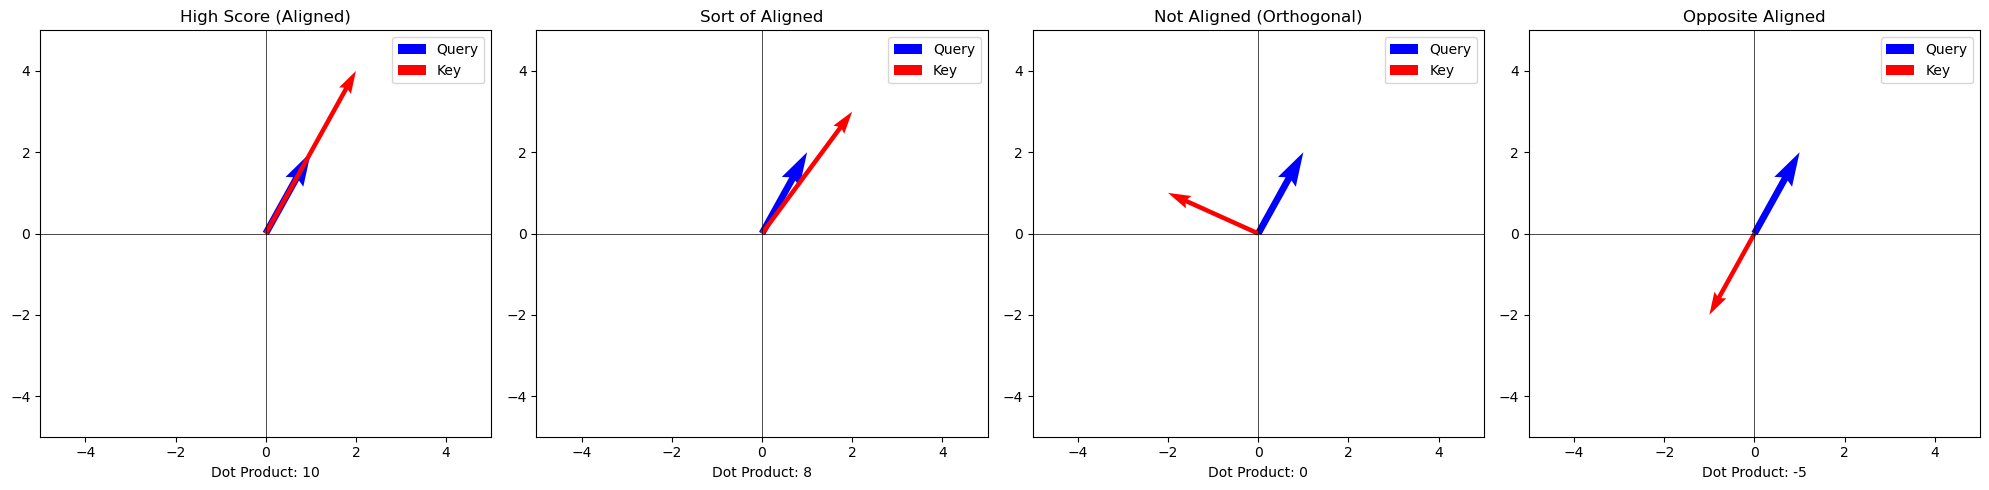

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_vectors_fixed(pairs, titles):
    # Determine number of plots based on how much data you provided
    num_plots = len(pairs)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
    
    # If there's only 1 plot, matplotlib returns a single axis, not a list
    if num_plots == 1:
        axes = [axes]

    for i in range(num_plots):
        ax = axes[i]
        v_query = np.array(pairs[i][0])
        v_key = np.array(pairs[i][1])
        
        # Plotting vectors
        ax.quiver(0, 0, v_query[0], v_query[1], angles='xy', scale_units='xy', 
                  scale=1, color='blue', label='Query', width=0.015)
        ax.quiver(0, 0, v_key[0], v_key[1], angles='xy', scale_units='xy', 
                  scale=1, color='red', label='Key', width=0.01)
        
        # Limits and styling
        limit = 5
        ax.set_xlim(-limit, limit)
        ax.set_ylim(-limit, limit)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_title(titles[i])
        ax.legend()
        
        # Display the math result
        dp = np.dot(v_query, v_key)
        ax.set_xlabel(f"Dot Product: {dp}")

    plt.tight_layout()
    plt.show()

# Data from your image
vector_data = [
    ([1, 2], [2, 4]),   # Case 1: Aligned
    ([1, 2], [2, 3]),   # Case 2: Sort of Aligned
    ([1, 2], [-2, 1]),   # Case 3: Not Aligned (Orthogonal)
    ([1, 2], [-1, -2])   # Opposite (180 degrees)
]

labels = ["High Score (Aligned)", "Sort of Aligned", "Not Aligned (Orthogonal)","Opposite Aligned"]

plot_attention_vectors_fixed(vector_data, labels)


1. **High Score (Aligned)Visual**: These words are highly relevant. For example, in our sentence, this would be the relationship between "bank" and "river."
2. **Sort of AlignedVisual**: T There is a strong relationship, but it's not the primary focus. This might be the relationship between "bank" and "flooded."
3. **Not Aligned (Orthogonal)Visual**: These words have no contextual relevance to each other. The model essentially "ignores" the Key word when processing the Query word. This might be the relationship between "bank" and "[SEP]".
4. **Opposite AlignedVisual**: The words are contextually "repelled" or incompatible. When the model applies the Softmax function later, this negative value will become a near-zero probability, ensuring no attention is paid here.

#### Value Matrix
- Function: Value vectors contain the detailed information of each token. For "river", the Value vector will have information that captures its characteristics as a geographical feature.
- Purpose: The value vectors are used to produce the final output of the attention mechanism. Essentially, these are the transformed embeddings that are weighted and summed based on the attention scores derived from the query-key similarity.
    - In essence, the value vector carries the "potential meanings" of a word, while the attention scores determine which of these meanings are most relevant in a given context. This combination allows the model to produce contextually appropriate outputs even when faced with words that have multiple meanings.
    - In our example with "bank" and "river", the standalone meaning of a word like "bank" might be ambiguous (riverbank or financial bank) or not fully informative. In such cases, the attention mechanism supplements the information in the value vector by focusing on the context provided by other words (like "river"). The attention scores determine how much each word's value vector should influence the final representation.
    - In summary, the value vector provides a foundation of knowledge about a word, and the attention mechanism refines this knowledge, enhancing it with contextual information to produce a nuanced and accurate interpretation of text.

The Value matrix is calculated by multiplying the input embedding matrix by a trainable weight matrix ($W_{V}$ ):

$V=X\cdot W_{V}$ 

Where:
- $X$ : The input matrix (Size: $n \times d_{model}$ ).
- $W_{V}$ : The Value Weight Matrix (Size: $d_{model} \times d_v$ ).
- $V$ : The resulting Value matrix (Size: $n \times d_v$ ).

For a single word like "river", the math for its $1 \times 3$  value vector would be:

$v_{river}=\left[\begin{matrix}x_{1}&x_{2}&x_{3}\end{matrix}\right]\cdot \left[\begin{matrix}w_{v11}&w_{v12}&w_{v13}\\ w_{v21}&w_{v22}&w_{v23}\\ w_{v31}&w_{v32}&w_{v33}\end{matrix}\right]$ 

This results in a vector $v = [v_1, v_2, v_3]$  where each component is the weighted sum of the input embedding.

Final Attention Output ($Z$ )The "Value" vectors are the only part of the word that actually "moves" through the model. Once we have the Attention Weights ($W$ ) from the Softmax step, we use them to create a weighted average of these Values:

$Z=W\cdot V$ 

#### Context-Aware

Context-Aware means that a word's mathematical meaning changes based on the words surrounding it.

In traditional computer systems, the word "bank" always has the same code. But a Context-Aware model (like a Transformer) realizes that "bank" in a forest is different from "bank" in a city.

The Real-World Difference
- Non-Context-Aware: Treats "bank" as a static dictionary definition.
- Context-Aware: Looks at the "neighbors" to decide the meaning.

![Context-Aware](image-13.png)

"Context-Awareness" is the result of the Aggregation step:
- **Isolation**: Every word starts as a generic embedding (The, bank, of, the, river...).
- **Attention**: The word "bank" sends out a Query to find relevant neighbors. It finds "river." 
- **Blending**: The model takes the Value vector of "river" and adds a piece of it into the vector for "bank."
- **Result**: The vector for "bank" is now "aware" of the "river." It has been contextually enriched.

Why is this important?

Without context-awareness, AI would struggle with:
- Sarcasm: "That's just great!" (Is it actually good, or bad?)
- Pronouns: "Ram hit the ball and it flew away." (What is "it"?)
- Ambiguity: Your "bank" example.

#### Final aggregation step of the Self-Attention mechanism & create a "context-aware" version of a specific word:


After calculating the weighted value vectors for each token based on the softmax weights, the next step is to aggregate these vectors to produce a single, context-enriched representation of the query word "river". This is achieved by summing the weighted value vectors:

#### Formula for Aggregation:

${Context\ Vector\ for\ <varible>}=\sum _{i=1}^{n}\text{Weighted\ Value\ Vector}_{i}$ 

Where ($n$ ) is the number of tokens in the sequence, and Weighted Value Vector is the weighted value vector for the $i^{th}$ token.

Summing Weighted Value Vectors for "River" The final context-aware representation for "River" is calculated by summing all the weighted value vectors for each token in the input sequence.

Output vector for "River" =
$[0.0593, 0.0668, 0.0743] + [0.1031, 0.1138, 0.1245] + [0.2158, 0.2340, 0.2525] + [0.1062, 0.1180, 0.1298] + \dots$ 

Final vector for "river" = $[1.5094, 1.6410, 1.7726]$ 

#### The Formula for Aggregation:

${Context\ Vector\ for\ River}=\sum _{i=1}^{n}\text{Weighted\ Value\ Vector}_{i}$

**Interpretation**:The resulting context vector for "River" encapsulates the influence of all other words in the sequence, giving a nuanced representation that goes beyond its standalone meaning to include contextual nuances influenced by the entire sentence.

#### Qus: How "River" Becomes Context-Aware?

Each word in your sentence ("The", "bank", "of", "the", "river", "was", "flooded") has its own Value Vector (its basic data). The attention mechanism assigns a weight (percentage) to each.
The word "Flooded" might have a high weight (e.g., 20%) because it strongly defines the state of the river. The word "of" might have a low weight (e.g., 1%) because it adds very little meaning. 

The Mixing (The Summation $\sum $ )The model takes the "portion" of each word (Weight $\times $  Value) and adds them together.In the text above, you see several vectors being added: $[0.0593 \dots] + [0.1031 \dots] + [0.2158 \dots]$ .Each of these represents a "contribution" from another word in the sentence.

The final vector $[1.5094, 1.6410, 1.7726]$  is no longer just the word "river." It is now a mathematical summary of the entire scene. It contains:
- The core identity of a River.
- The "spatial" context from the word Bank.
- The "state" context from the word Flooded.
If you pass this final vector to a translation task, the model won't just see "River"; it will see "A river that is high/overflowing near its banks." This prevents the model from making simple mistakes and allows it to understand complex human language.

#### Multi-Head Attention (MHA):

Multi-Head Attention (MHA) is like having a team of experts looking at the same sentence simultaneously, but each expert focuses on a different relationship.While a single attention head might only notice that "river" is near "bank," Multi-Head Attention allows the model to realize that "bank" is a place, "river" is the reason for the "flood," and "the" is just a grammatical marker—all at once.

![Multi-Head Attention](image-16.png)

#### Multi-Head Attention Parallel Perspectives

Instead of performing the attention calculation once on the full embedding (e.g., 768 dimensions), the model splits the embedding into smaller pieces (heads). If your model has **8 heads** and a total **dimension of 768**, each head works on a **96-dimensional** space ($768 / 8 = 96$).
- Head 1: Might focus on Grammar (matching "was" with "flooded").
- Head 2: Might focus on Vocabulary (matching "bank" with "river").
- Head 3: Might focus on History (looking back at previous sentences).

The process follows four main steps for every head ($h$ ):
- **Linear Projection**: Each head has its own set of weight matrices: $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$
- Independent Attention: Each head calculates its own Attention Score and Context Vector ($Z_{h}$ ) using the formula we discussed earlier:

$Z_{h}=\text{softmax}\left(\frac{Q_{h}K_{h}^{T}}{\sqrt{d_{k}}}\right)V_{h}$ 

- Concatenation: All the individual context vectors ($Z_1, Z_2, \dots, Z_8$ ) are glued together side-by-side.Final Projection: The concatenated vector is multiplied by a final weight matrix ($W_{O}$ ) to bring it back to the original size (768).

The resulting context vector for "River" encapsulates the influence of all other words in the sequence, giving a nuanced representation that goes beyond its standalone meaning to include contextual nuances influenced by the entire sentence or sequence. This vector can then be used for further processing in the neural network, such as in downstream tasks like classification, translation, or other forms of language understanding and generation.

#### Multiple Parallel Attention Heads:
- The input sentence (sequence of token embeddings) is processed by multiple (e.g., 12) attention heads in parallel.
- Each attention head computes a separate attention mechanism independently but using the same input token embeddings.
- Each attention head has its own set of Query, Key and Value Matrices.
- Parallel Operation: All 12 attention heads within a layer process the input data at the same time, independently from each other.
- For our example, for simplicity we only have a single head, and no multi head attention.

#### Focus Areas for Groups of Attention Heads:
- Heads 1-12 (Layer 1): Focus on basic syntax and grammar: Capturing essential grammatical structures, such as subject-verb agreement, tense, and basic sentence parsing.
- Heads 13-24 (Layer 2): Address lexical relationships: Analyze the relationships between nouns, verbs, and adjectives, understanding how they interact to convey meaning within sentences.
- Heads 25-36 (Layer 3): Enhance contextual understanding: Dive deeper into the context of phrases and clauses, recognizing the relevance and implications of the surrounding text.
- Heads 37-48 (Layer 4): Process semantic roles and dependencies: Identify and interpret the roles entities play in a sentence, understanding complex dependencies and semantic relationships.
- Heads 49-60 (Layer 5): Manage discourse and narrative flow: Analyze how elements like conjunctions, discourse markers, and overall text structure guide the logical flow and coherence of paragraphs and larger text bodies.
- Heads 61-72 (Layer 6): Specialized analysis and integration: Tackle specialized topics, pragmatic cues, emotional tone, and potentially multimodal data integration (if extended beyond the original model capabilities). This can include sentiment analysis, figurative language interpretation, and complex intertextual connections.

#### Output of Attention Heads:
Each attention head generates a context-aware vector for each token in the input sequence.
#### Combining Outputs:
Since there are 12 heads in each transformer layer of DistilBERT, this means for each token, you end up with 12 different vectors from each layer.

#### **Concatenation**: 

This longer vector now encapsulates the information from all 12 attention heads.Multi-head attention consists of multiple single attention heads operating in parallel. Each head independently computes its attention output, focusing on different aspects of the input. The outputs from all heads are then concatenated into a single vector and passed through a final linear transformation, allowing the model to capture diverse information.

Concatenated vector for "bank" = $([0.1 \quad 0.2 \quad 0.3 \quad 0.4 \quad 0.5 \quad 0.6 \quad 0.7 \quad 0.8 \quad 0.9 \quad 1.0 \quad 1.1 \quad 1.2 \quad 1.3 \quad 1.4 \quad 1.5 \quad 1.6 \quad 1.7 \dots])$

The output vectors you see listed for each of the 12 attention heads would represent the context-aware vectors for the token "bank" generated within one single transformer layer of DistilBERT. The concatenated vector at the end is the combination of all these individual vectors from the 12 heads in that layer, forming a richer, multidimensional representation of the token. This concatenated vector then feeds into subsequent layers or is used in further processing tasks within the model.

**After concatenation**:

**Transformation**: The concatenated vector for each token then passes through a feed-forward neural network within the same transformer layer. This network usually consists of two linear transformations with a ReLU activation in between. It's designed to further process the information and integrate the features extracted by the attention mechanism.

**Residual Connection**: The output of the feed-forward network is added back to the input of the layer (before the attention heads) via a residual connection. This helps in combating the vanishing gradient problem by allowing gradients to flow directly through the network.

**Layer Normalization**: After the residual connection, layer normalization is applied. This step normalizes the vector to have zero mean and unit variance, helping to stabilize the learning process.

#### Mask Language Modeling (MLM)

![MLM](image-17.png)

